# 可选实验 - 简单神经网络
在本实验中，我们将使用Tensorflow构建一个小型神经网络。
   <center> <img  src="./images/C2_W1_CoffeeRoasting.png" width="400" />   <center/>


In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('./deeplearning.mplstyle')
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from lab_utils_common import dlc
from lab_coffee_utils import load_coffee_data, plt_roast, plt_prob, plt_layer, plt_network, plt_output_unit
import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)


I0000 00:00:1781366875.309191   90281 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781366875.484285   90281 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781366877.962957   90281 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 数据集

In [2]:
X,Y = load_coffee_data();
print(X.shape, Y.shape)

(200, 2) (200, 1)


让我们在下面绘制咖啡烘焙数据。两个特征分别是温度（摄氏度）和时间（分钟）。[在家烘焙咖啡](https://www.merchantsofgreencoffee.com/how-to-roast-green-coffee-in-your-oven/)建议时间最好保持在12到15分钟之间，温度应在175到260摄氏度之间。当然，随着温度升高，时间应该缩短。

/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 38271 (\N{CJK UNIFIED IDEOGRAPH-957F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 38047 (\N{CJK UNIFIED IDEOGRAPH-949F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21654 (\N{CJK UNIFIED IDEOGRAPH-5496}) m

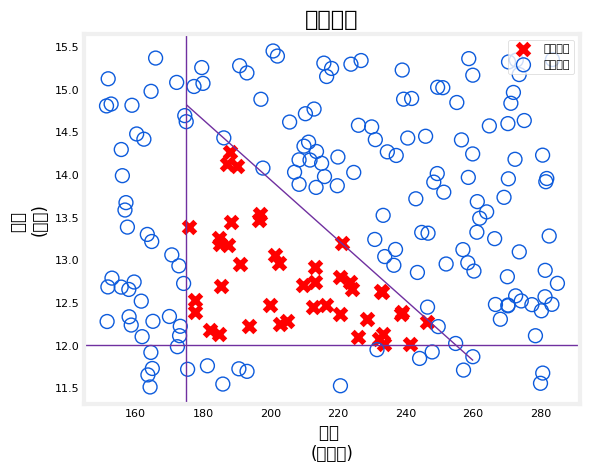

In [22]:
plt_roast(X,Y)

### 归一化数据
如果数据被归一化，拟合权重到数据（反向传播，将在下周的讲座中介绍）的过程会更快。这与你在课程1中使用的程序相同，其中数据的每个特征都被归一化到相似的范围。
下面的程序使用了一个Keras[归一化层](https://keras.io/api/layers/preprocessing_layers/numerical/normalization/)。它有以下步骤：
- 创建一个"归一化层"。注意，如这里所应用的，这不是你模型中的一个层。
- 'adapt'数据。这将学习数据集的均值和方差，并在内部保存这些值。
- 归一化数据。  
对任何使用学习模型的未来数据应用归一化是很重要的。

In [3]:
print(f"Temperature Max, Min pre normalization: {np.max(X[:,0]):0.2f}, {np.min(X[:,0]):0.2f}")
print(f"Duration    Max, Min pre normalization: {np.max(X[:,1]):0.2f}, {np.min(X[:,1]):0.2f}")
norm_l = tf.keras.layers.Normalization(axis=-1)
norm_l.adapt(X)  # learns mean, variance
Xn = norm_l(X)
print(f"Temperature Max, Min post normalization: {np.max(Xn[:,0]):0.2f}, {np.min(Xn[:,0]):0.2f}")
print(f"Duration    Max, Min post normalization: {np.max(Xn[:,1]):0.2f}, {np.min(Xn[:,1]):0.2f}")

Temperature Max, Min pre normalization: 284.99, 151.32
Duration    Max, Min pre normalization: 15.45, 11.51
Temperature Max, Min post normalization: 1.66, -1.69
Duration    Max, Min post normalization: 1.79, -1.70


W0000 00:00:1781366891.779919   90281 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


平铺/复制我们的数据以增加训练集大小并减少训练轮数。

In [4]:
Xt = np.tile(Xn,(1000,1))
Yt= np.tile(Y,(1000,1))   
print(Xt.shape, Yt.shape)   

(200000, 2) (200000, 1)


## Tensorflow模型

### 模型
   <center> <img  src="./images/C2_W1_RoastingNetwork.PNG" width="200" />   <center/>  
让我们构建讲座中描述的"咖啡烘焙网络"。如下所示，有两个带有sigmoid激活函数的层：

In [5]:
tf.random.set_seed(1234)  # 设置随机种子以获得一致的结果
model = Sequential(
    [
        tf.keras.Input(shape=(2,)),
        Dense(3, activation='sigmoid', name = 'layer1'),
        Dense(1, activation='sigmoid', name = 'layer2')
     ]
)

>**注意1：** `tf.keras.Input(shape=(2,)),`指定了输入的期望形状。这允许Tensorflow在此处调整权重和偏置参数的大小。这在探索Tensorflow模型时很有用。在实践中可以省略此语句，Tensorflow会在`model.fit`语句中指定输入数据时调整网络参数。  
>**注意2：** 在最后一层包含sigmoid激活函数不被认为是最佳实践。相反，它应该在损失函数中考虑，这可以提高数值稳定性。这将在后面的实验中更详细地描述。

`model.summary()`提供了网络的描述：

In [26]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer1 (Dense)                  │ (None, 3)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer2 (Dense)                  │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13 (52.00 B)

 Trainable params: 13 (52.00 B)

 Non-trainable params: 0 (0.00 B)

摘要中显示的参数计数对应于权重和偏置数组中的元素数量，如下所示。

In [27]:
L1_num_params = 2 * 3 + 3   # W1参数 + b1参数
L2_num_params = 3 * 1 + 1   # W2参数 + b2参数
print("L1 params = ", L1_num_params, ", L2 params = ", L2_num_params  )

L1 params =  9 , L2 params =  4


让我们检查Tensorflow实例化的权重和偏置。权重$W$的大小应为（输入特征数，层中单元数），而偏置$b$的大小应与层中的单元数匹配：
- 在第一层有3个单元，我们期望W的大小为(2,3)，$b$应有3个元素。
- 在第二层有1个单元，我们期望W的大小为(3,1)，$b$应有1个元素。

In [28]:
W1, b1 = model.get_layer("layer1").get_weights()
W2, b2 = model.get_layer("layer2").get_weights()
print(f"W1{W1.shape}:\n", W1, f"\nb1{b1.shape}:", b1)
print(f"W2{W2.shape}:\n", W2, f"\nb2{b2.shape}:", b2)

W1(2, 3):
 [[ 0.77 -0.16 -0.39]
 [-0.95  0.12 -0.83]] 
b1(3,): [0. 0. 0.]
W2(3, 1):
 [[ 0.51]
 [-0.81]
 [ 0.45]] 
b2(1,): [0.]


以下语句将在第2周详细描述。目前：
- `model.compile`语句定义了损失函数并指定了编译优化器。
- `model.fit`语句运行梯度下降并将权重拟合到数据。

In [6]:
model.compile(
    loss = tf.keras.losses.BinaryCrossentropy(),
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.01),
)

model.fit(
    Xt,Yt,            
    epochs=10,
)

Epoch 1/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 0.1827
Epoch 2/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 0.1274
Epoch 3/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 0.1148
Epoch 4/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 0.0393
Epoch 5/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - loss: 0.0151
Epoch 6/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 0.0100
Epoch 7/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - loss: 0.0070
Epoch 8/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 0.0049
Epoch 9/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 0.0035
Epoch 10/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 0.0026


#### 轮数和批次
在上面的`compile`语句中，`epochs`的数量被设置为10。这指定了整个数据集在训练期间应被应用10次。在训练期间，你会看到描述训练进度的输出，看起来像这样：
```
Epoch 1/10
6250/6250 [==============================] - 6s 910us/step - loss: 0.1782
```
第一行`Epoch 1/10`描述了模型当前正在运行的轮次。为了效率，训练数据集被分成'批次'。Tensorflow中批次的默认大小是32。我们扩展的数据集中有200000个样本，即6250个批次。第二行的符号`6250/6250 [====`描述了已经执行了哪个批次。

#### 更新后的权重
拟合后，权重已被更新：

In [30]:
W1, b1 = model.get_layer("layer1").get_weights()
W2, b2 = model.get_layer("layer2").get_weights()
print("W1:\n", W1, "\nb1:", b1)
print("W2:\n", W2, "\nb2:", b2)

W1:
 [[13.77 13.31 -0.04]
 [ 0.27 11.1  11.04]] 
b1: [14.44  1.35 13.37]
W2:
 [[ 27.95]
 [-37.81]
 [ 27.58]] 
b2: [-36.37]


接下来，我们将加载之前训练运行中保存的一些权重。这样做是为了使本notebook对Tensorflow随时间的变化保持鲁棒性。不同的训练运行可能产生略有不同的结果，下面的讨论适用于特定的解决方案。可以自由地注释掉此单元格重新运行notebook以查看差异。

In [7]:
W1 = np.array([
    [-8.94,  0.29, 12.89],
    [-0.17, -7.34, 10.79]] )
b1 = np.array([-9.87, -9.28,  1.01])
W2 = np.array([
    [-31.38],
    [-27.86],
    [-32.79]])
b2 = np.array([15.54])
model.get_layer("layer1").set_weights([W1,b1])
model.get_layer("layer2").set_weights([W2,b2])

### 预测
<img align="left" src="./images/C2_W1_RoastingDecision.PNG"     style=" width:380px; padding: 10px 20px; " >

一旦你有了训练好的模型，就可以用它进行预测。回想一下，我们模型的输出是一个概率。在这种情况下，是良好烘焙的概率。为了做出决策，必须将概率与阈值进行比较。在这种情况下，我们将使用0.5。

让我们从创建输入数据开始。模型期望一个或多个样本，样本在矩阵的行中。在这种情况下，我们有两个特征，所以矩阵将是(m,2)，其中m是样本数量。
回想一下，我们已经归一化了输入特征，所以我们也必须归一化测试数据。   
要进行预测，你需要应用`predict`方法。

In [32]:
X_test = np.array([
    [200,13.9],  # 正面样本
    [200,17]])   # 负面样本
X_testn = norm_l(X_test)
predictions = model.predict(X_testn)
print("predictions = \n", predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
predictions = 
 [[9.63e-01]
 [3.03e-08]]


要将概率转换为决策，我们应用阈值：

In [33]:
yhat = np.zeros_like(predictions)
for i in range(len(predictions)):
    if predictions[i] >= 0.5:
        yhat[i] = 1
    else:
        yhat[i] = 0
print(f"decisions = \n{yhat}")

decisions = 
[[1.]
 [0.]]


可以用更简洁的方式实现：

In [34]:
yhat = (predictions >= 0.5).astype(int)
print(f"decisions = \n{yhat}")

decisions = 
[[1]
 [0]]


## 层函数
让我们检查单元的函数，以确定它们在咖啡烘焙决策中的作用。我们将绘制每个节点在所有输入值（时间，温度）下的输出。每个单元是一个逻辑函数，其输出范围从零到一。图中的阴影代表输出值。
> 注意：在实验中，我们通常从零开始编号，而讲座中可能从1开始。

/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 31532 (\N{CJK UNIFIED IDEOGRAPH-7B2C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 23618 (\N{CJK UNIFIED IDEOGRAPH-5C42}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21333 (\N{CJK UNIFIED IDEOGRAPH-5355}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20803 (\N{CJK UNIFIED IDEOGRAPH-5143}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


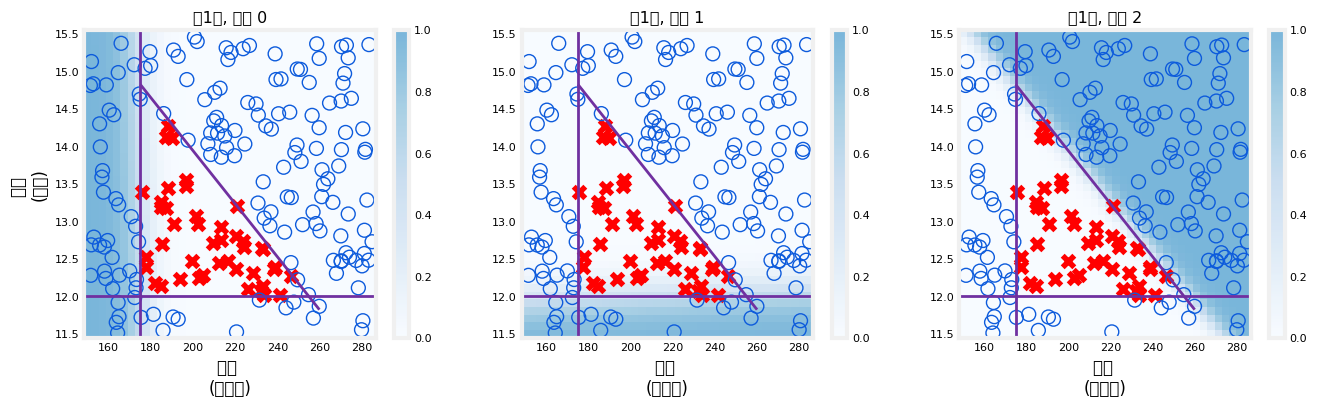

In [35]:
plt_layer(X,Y.reshape(-1,),W1,b1,norm_l)

阴影显示每个单元负责不同的'烘焙失败'区域。当温度过低时，单元0的值较大。当时间过短时，单元1的值较大，而对于时间/温度的不良组合，单元2的值较大。值得注意的是，网络通过梯度下降过程自行学习了这些函数。它们与人为选择来做相同决策的函数非常相似。

最后一层的函数图有点难以可视化。它的输入是第一层的输出。我们知道第一层使用sigmoid，所以它们的输出范围在零到一之间。我们可以创建一个3D图，计算三个输入的所有可能组合的输出。如下所示。上面，高输出值对应于'烘焙失败'区域。下面，最大输出在三个输入都是小值的区域，对应于'良好烘焙'区域。

/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 36755 (\N{CJK UNIFIED IDEOGRAPH-8F93}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20986 (\N{CJK UNIFIED IDEOGRAPH-51FA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


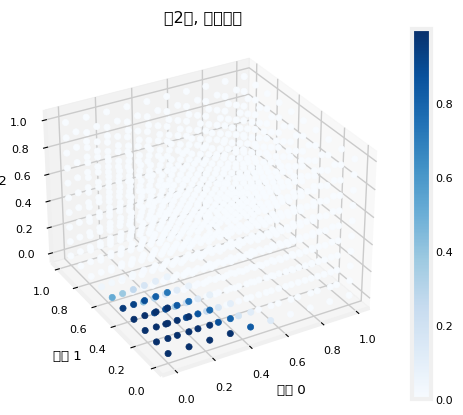

In [36]:
plt_output_unit(W2,b2)

最后一张图展示了整个网络的运行情况。  
左图是最后一层的原始输出，用蓝色阴影表示。这叠加在由X和O表示的训练数据上。   
右图是网络在决策阈值后的输出。这里的X和O对应于网络做出的决策。  
以下内容需要一些时间来运行

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━

/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/events.py:100: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/events.py:100: UserWarning: Glyph 38271 (\N{CJK UNIFIED IDEOGRAPH-957F}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/events.py:100: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/events.py:100: UserWarning: Glyph 38047 (\N{CJK UNIFIED IDEOGRAPH-949F}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/dev/gpu/.venv/lib/python3.13/site-packages/IPython/core/events.py:100: UserWarning: Glyph 32593 (\N{CJK UNIFIED IDEOGRAPH-7F51}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/dev/gpu/.venv/lib/python3.13/

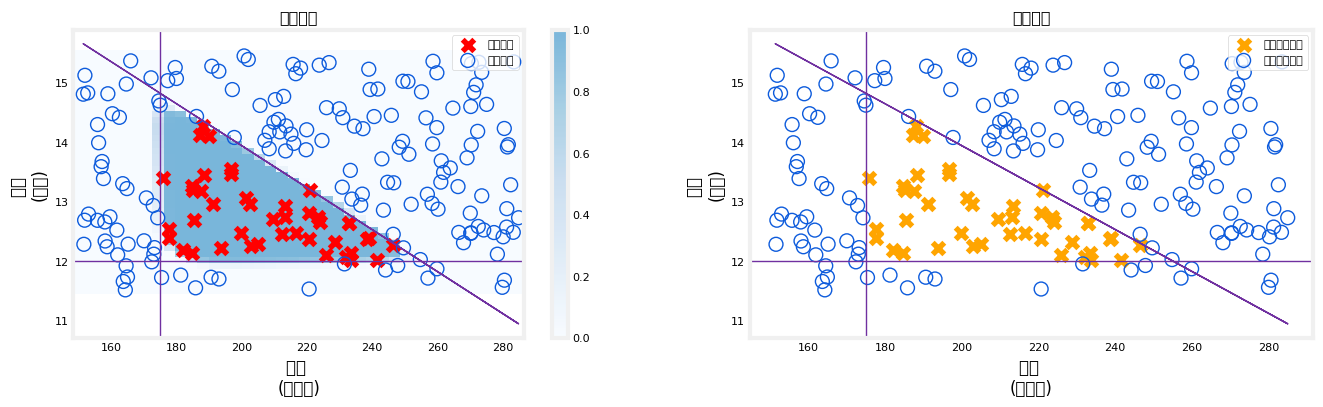

In [8]:
netf= lambda x : model.predict(norm_l(x))
plt_network(X,Y,netf)

## 恭喜！
你已经在Tensorflow中构建了一个小型神经网络。 
该网络展示了神经网络通过将决策分配给多个单元来处理复杂决策的能力。